In [1]:
from collections import Counter
import random
import yaml
from omegaconf import OmegaConf
from PIL import Image
import os

import numpy as np
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Dataset

from tqdm.auto import tqdm

In [2]:
# 1. Определяем путь для сохранения датасета
data_path = '../data'
os.makedirs(data_path, exist_ok=True)
print(f"Датасет будет загружен и сохранен в: {os.path.abspath(data_path)}")

# 2. Скачиваем и распаковываем датасет с помощью torchvision
# torchvision сам обработает скачивание и распаковку .tar.gz файла
# download=True сработает только если датасета нет в указанной папке
try:
    print("Начинается загрузка тренировочного сплита (это может занять много времени, ~5GB)...")
    # Мы загружаем 'train', torchvision автоматически скачает весь архив, если его нет
    train_dataset = torchvision.datasets.Food101(root=data_path, split='train', download=True)
    print("Тренировочный сплит успешно проверен/загружен.")

    print("\nПроверка тестового сплита...")
    # Второй вызов уже не будет ничего качать, а только проверит наличие
    test_dataset = torchvision.datasets.Food101(root=data_path, split='test', download=True)
    print("Тестовый сплит успешно проверен.")
    
    print("\nДатасет Food-101 полностью готов для локального использования.")
    
    # Проверим ожидаемую структуру папок
    food101_path = os.path.join(data_path, 'food-101')
    if os.path.exists(food101_path):
        print(f"Проверка: папка 'food-101' найдена в '{data_path}'")
        print("Структура папок корректна.")
    else:
        # torchvision может создать папку food-101-dataset-split
        food101_alt_path = os.path.join(data_path, 'food-101-dataset-split')
        if os.path.exists(food101_alt_path):
             print(f"Проверка: папка 'food-101-dataset-split' найдена в '{data_path}'")
             print("Структура папок корректна.")
        else:
            print(f"Внимание: ожидаемая папка 'food-101' или 'food-101-dataset-split' не найдена в '{data_path}'")

except Exception as e:
    print(f"\nПроизошла ошибка во время загрузки: {e}")
    print("Пожалуйста, проверьте интернет-соединение и наличие свободного места на диске (нужно ~5GB).")


Датасет будет загружен и сохранен в: c:\Users\User\Documents\Progs\Projects\food101_nas\data
Начинается загрузка тренировочного сплита (это может занять много времени, ~5GB)...
Тренировочный сплит успешно проверен/загружен.

Проверка тестового сплита...
Тестовый сплит успешно проверен.

Датасет Food-101 полностью готов для локального использования.
Проверка: папка 'food-101' найдена в '../data'
Структура папок корректна.


In [3]:
torch.manual_seed(42)
random.seed(42)

In [4]:
# CONFIG
cfg = OmegaConf.load("../configs/base.yaml")

print("Config:", cfg)

Config: {'dataset': {'name': 'food101', 'source': 'local', 'path': './data', 'num_classes': 101}, 'train': {'epochs': 5, 'batch_size': 16, 'shuffle': True, 'lr': 0.0001, 'weight_decay': 0.01, 't_max': 10, 'label_smoothing': 0.05, 'gradient_clip': 1.0, 'save_best': True, 'seed': 42, 'manual_seed_enabled': True, 'cutmix': True}, 'val': {'batch_size': 8, 'shuffle': False}, 'transforms': {'common': {'resize': 224, 'mean': [0.5450310707092285, 0.4435403347015381, 0.3436422348022461], 'std': [0.2694936692714691, 0.27188628911972046, 0.2766088843345642]}, 'train': {'horizontal_flip_p': 0.5, 'random_rotation_deg': 15, 'random_crop_scale': [0.8, 1.0], 'color_jitter': {'brightness': 0.2, 'contrast': 0.2, 'saturation': 0.2}, 'gaussian_noise': {'mean': 0.0, 'std': 0.01}, 'cutmix': {'alpha': 1.0, 'prob': 0.5}}, 'val': None}, 'hardware': {'num_workers': 0, 'pin_memory': False, 'grad_accum_steps': 1, 'device': 'cpu'}}


In [5]:
# --- 1. Загрузка датасетов из локальной папки ---
# Путь к данным определен в ячейке скачивания
data_path = '../data'

# Загружаем тренировочный и валидационный (тестовый) сплиты
# download=False, т.к. мы уже скачали данные на предыдущем шаге
train_dataset = torchvision.datasets.Food101(root=data_path, split='train', download=False)
val_dataset = torchvision.datasets.Food101(root=data_path, split='test', download=False)

print(f"Количество изображений в train split: {len(train_dataset)}")
print(f"Количество изображений в val split: {len(val_dataset)}")

# --- 2. Загрузка названий классов ---
# Названия классов лежат в отдельном файле
classes_file_path = os.path.join(data_path, 'food-101/meta/classes.txt')
with open(classes_file_path, 'r') as f:
    class_names = [line.strip().replace('_', ' ') for line in f.readlines()]

print(f"\nВсего классов: {len(class_names)}")
print(f"Пример класса: {class_names[0]}")


Количество изображений в train split: 75750
Количество изображений в val split: 25250

Всего классов: 101
Пример класса: apple pie


Пример изображения (индекс 18289):
  - Тип изображения: <class 'PIL.Image.Image'>
  - Размер: (512, 512)
  - Метка (индекс): 45
  - Название класса: 'frozen yogurt'


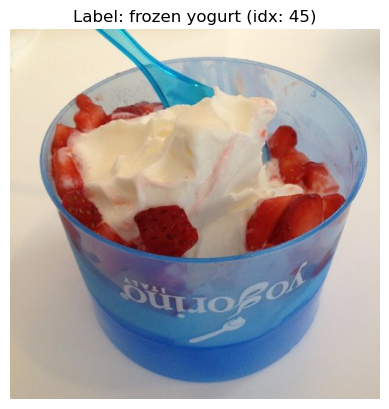

In [11]:
# --- 3. Визуализация случайного примера ---
# Убедимся, что данные и метки загрузились корректно

sample_idx = random.randint(0, len(train_dataset) - 1)
image, label_idx = train_dataset[sample_idx]

print(f"Пример изображения (индекс {sample_idx}):")
print(f"  - Тип изображения: {type(image)}")
print(f"  - Размер: {image.size}")
print(f"  - Метка (индекс): {label_idx}")
print(f"  - Название класса: '{class_names[label_idx]}'")


plt.imshow(image)
plt.title(f"Label: {class_names[label_idx]} (idx: {label_idx})")
plt.axis("off")
plt.show()


## 2. Вычисление среднего и стандартного отклонения (MEAN, STD)

In [41]:
# Для подсчета MEAN/STD нам нужен датасет, который возвращает только тензоры картинок
img_size = cfg.transforms.common.resize

# Определяем трансформацию: просто изменение размера и перевод в тензор
transform_for_stats = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor()
])

# Создаем специальный класс датасета для этой задачи
class StatsDataset(torch.utils.data.Dataset):
    def __init__(self, tv_dataset, transform=None):
        self.dataset = tv_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        # tv_dataset возвращает (image, label), нам нужно только изображение
        img, _ = self.dataset[idx]
        img = img.convert("RGB") # На всякий случай, если есть Ч/Б
        if self.transform:
            img = self.transform(img)
        return img

# Создаем экземпляр датасета и загрузчик
stats_ds = StatsDataset(train_dataset, transform=transform_for_stats)
loader = DataLoader(stats_ds, batch_size=64, shuffle=False, num_workers=0)

# Проверим, что все работает
img_tensor = stats_ds[0]
print(f"Размер тензора из StatsDataset: {img_tensor.shape}")

Размер тензора из StatsDataset: torch.Size([3, 224, 224])


In [72]:
sum_    = torch.zeros(3, dtype=torch.float64)
sum_sq  = torch.zeros(3, dtype=torch.float64)
n_pix   = 0

for imgs in tqdm(loader):
    imgs = imgs.to(dtype=torch.float64)  # [B,3,H,W]
    b, c, h, w = imgs.shape
    sum_   += imgs.sum(dim=(0,2,3))
    sum_sq += (imgs**2).sum(dim=(0,2,3))
    n_pix  += b*h*w

mean = sum_ / n_pix  # выборочное среднее

# Несмещённая дисперсия: знаменатель N-1
# var = (Σx_i^2 - N * mean^2) / (N-1)
var  = (sum_sq - n_pix * mean**2) / (n_pix - 1)
std  = torch.sqrt(torch.clamp(var, min=0))

mean = mean.to(torch.float32).tolist()
std  = std.to(torch.float32).tolist()

print("Food-101 mean:", mean)
print("Food-101 std :", std)

mean_std = {
    "mean": mean,
    "std": std
}

cfg.transforms.common.mean = mean
cfg.transforms.common.std  = std

with open("../configs/base.yaml", "w") as f:
    OmegaConf.save(cfg, f)

100%|██████████| 1184/1184 [05:58<00:00,  3.30it/s]

Food-101 mean: [0.5450310707092285, 0.4435403347015381, 0.3436422348022461]
Food-101 std : [0.2694936692714691, 0.27188628911972046, 0.2766088843345642]


In [73]:
cfg = OmegaConf.load("../configs/base.yaml")

print("Common stats:", cfg.transforms.common)
print("Loaded mean:", cfg.transforms.common.mean)
print("Loaded std :", cfg.transforms.common.std)

mean = cfg.transforms.common.mean
std  = cfg.transforms.common.std

Common stats: {'resize': 224, 'mean': [0.5450310707092285, 0.4435403347015381, 0.3436422348022461], 'std': [0.2694936692714691, 0.27188628911972046, 0.2766088843345642]}
Loaded mean: [0.5450310707092285, 0.4435403347015381, 0.3436422348022461]
Loaded std : [0.2694936692714691, 0.27188628911972046, 0.2766088843345642]


# Нормализация + аугументация

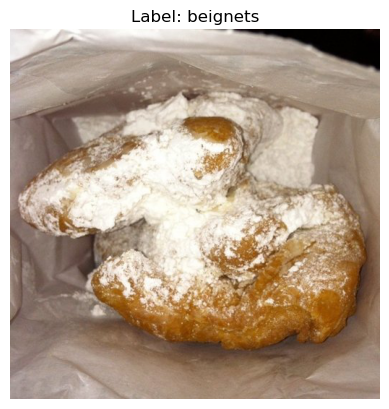

Transformed shape: torch.Size([3, 224, 224])


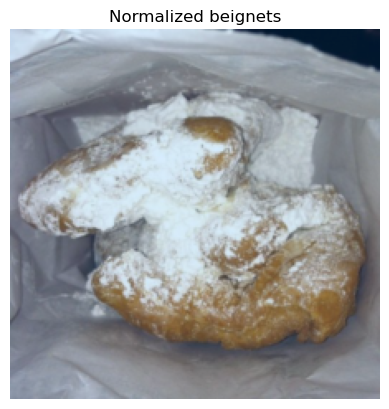

In [ ]:
# ImageNet-style нормализация

example = train_dataset[4]
img, label = example

plt.imshow(img)
plt.title(f"Label: {class_names[label]}")
plt.axis("off")
plt.show()

img_size = cfg.transforms.common.resize

normalization = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

# Проверим на одной картинке
img_t = normalization(img)
print("Transformed shape:", img_t.shape)

# Картинку рисовать бессмысленно, т.к. она нормализована
# Но можно сделать min-max отображение, просто чтобы посмотреть на нее (приобретает смысл если мы дополнительно делаем аугментации)
img_t = img_t.permute(1, 2, 0).cpu().numpy()    # permute для перевода из [C,H,W] в [H,W,C] (формат plt)
img_t = (img_t - img_t.min()) / (img_t.max() - img_t.min())

plt.imshow(img_t)
plt.title(f"Normalized {class_names[label]}")
plt.axis("off")
plt.show()

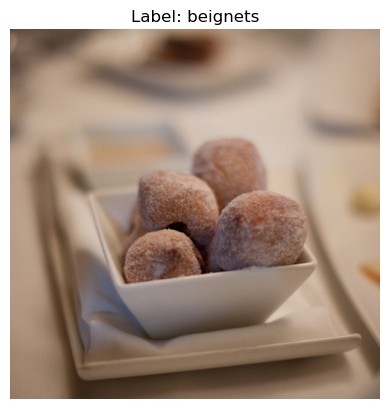

Transformed shape: torch.Size([3, 224, 224])


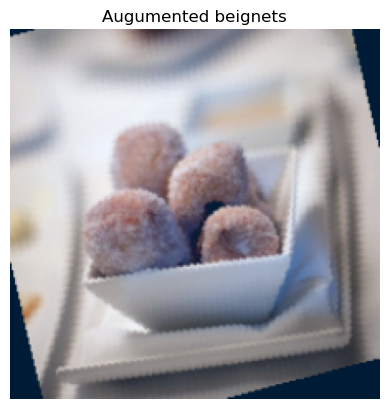

In [ ]:
# аугументации

example = train_dataset[5]
img, label = example

plt.imshow(img)
plt.title(f"Label: {class_names[label]}")
plt.axis("off")
plt.show()

img_size = cfg.transforms.common.resize

augumentation = T.Compose([
    T.Resize((img_size, img_size)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomResizedCrop(img_size, scale=(0.8, 1.0)), 
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

img_t = augumentation(img)
print("Transformed shape:", img_t.shape)

img_t = img_t.permute(1, 2, 0).cpu().numpy()    # permute для перевода из [C,H,W] в [H,W,C] (формат plt)
img_t = (img_t - img_t.min()) / (img_t.max() - img_t.min())

plt.imshow(img_t)
plt.title(f"Augmented {class_names[label]}")
plt.axis("off")
plt.show()

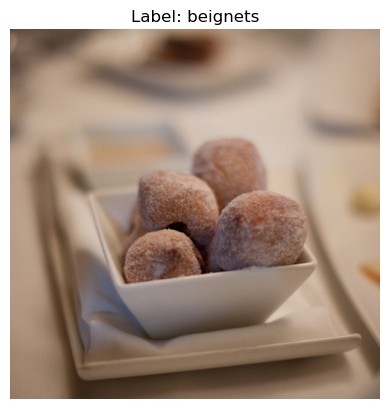

Transformed shape: torch.Size([3, 224, 224])


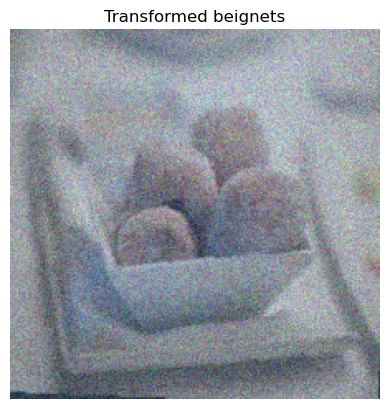

In [ ]:
# аугументации + легкий гауссовый шум
cfg = OmegaConf.load("../configs/base.yaml")

class GaussianNoise(torch.nn.Module):
    def __init__(self, mean=0.0, std=0.01):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        if self.std > 0:
            noise = torch.randn_like(tensor) * self.std + self.mean
            return tensor + noise
        return tensor

transform_train = T.Compose([
    T.Resize((cfg.transforms.common.resize, cfg.transforms.common.resize)),
    T.RandomHorizontalFlip(p=cfg.transforms.train.horizontal_flip_p),
    T.RandomRotation(cfg.transforms.train.random_rotation_deg),
    T.RandomResizedCrop(
        cfg.transforms.common.resize, 
        scale=tuple(cfg.transforms.train.random_crop_scale)
    ),
    T.ColorJitter(
        brightness=cfg.transforms.train.color_jitter.brightness,
        contrast=cfg.transforms.train.color_jitter.contrast,
        saturation=cfg.transforms.train.color_jitter.saturation,
    ),
    T.ToTensor(),
    GaussianNoise(
        mean=cfg.transforms.train.gaussian_noise.mean,
        std=cfg.transforms.train.gaussian_noise.std,
    ),
    T.Normalize(mean=cfg.transforms.common.mean, std=cfg.transforms.common.std),
])

example = train_dataset[5]
img, label = example

plt.imshow(img)
plt.title(f"Label: {class_names[label]}")
plt.axis("off")
plt.show()

img_t = transform_train(img)
print("Transformed shape:", img_t.shape)

img_t = img_t.permute(1, 2, 0).cpu().numpy()    # permute для перевода из [C,H,W] в [H,W,C] (формат plt)
img_t = (img_t - img_t.min()) / (img_t.max() - img_t.min())

plt.imshow(img_t)
plt.title(f"Transformed {class_names[label]}")
plt.axis("off")
plt.show()

# Проверка работоспособности norm + aug

In [77]:
transform_val = T.Compose([
    T.Resize((cfg.transforms.common.resize, cfg.transforms.common.resize)),
    T.ToTensor(),
    T.Normalize(mean=cfg.transforms.common.mean, std=cfg.transforms.common.mean),
])

In [ ]:
class FoodDataset(Dataset):
    def __init__(self, tv_dataset, transform=None):
        self.dataset = tv_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = img.convert("RGB")    # Преобразуем в RGB, т.к. есть ч.-б. изображения
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = FoodDataset(train_dataset, transform=transform_train)
val_ds  = FoodDataset(val_dataset,  transform=transform_val)

In [79]:
train_loader = DataLoader(train_ds,
                          batch_size=cfg.train.batch_size,
                          shuffle=False,
                          num_workers=0)  # в ноутбуке оставляем 0

batch = next(iter(train_loader))
imgs, labels = batch

print("Batch images:", imgs.shape)   # [B, 3, 224, 224]
print("Batch labels:", labels.shape) # [B]

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])


In [80]:
val_loader = DataLoader(val_ds,
                          batch_size=cfg.val.batch_size,
                          shuffle=cfg.val.shuffle,
                          num_workers=0)

batch = next(iter(val_loader))
imgs, labels = batch

print("Batch images:", imgs.shape)   # [B, 3, 224, 224]
print("Batch labels:", labels.shape) # [B]

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])


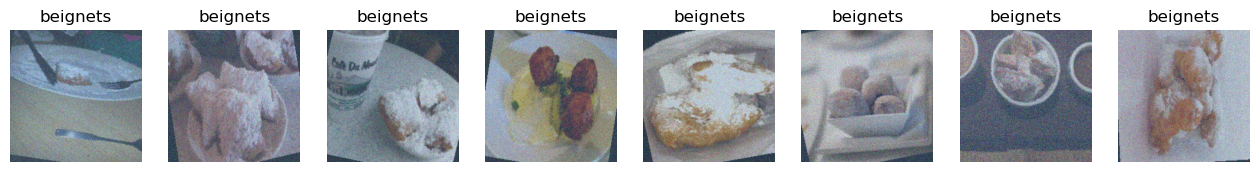

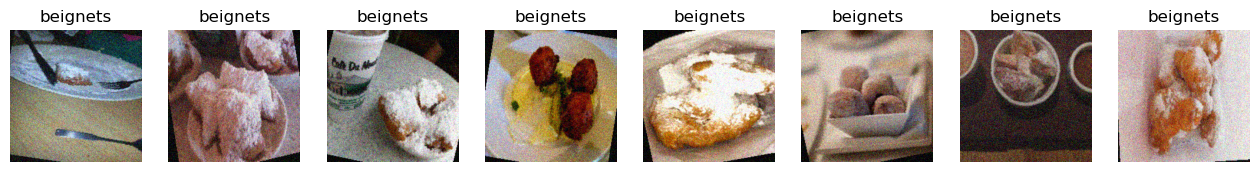

In [ ]:
class Denormalize(torch.nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def forward(self, tensor):
        return tensor * self.std + self.mean

def show_batch(images, labels, classes, mean, std, n=8, denorm=True):
    denorm_transform = Denormalize(mean, std)
    plt.figure(figsize=(16, 4))
    for i in range(n):
        ax = plt.subplot(1, n, i+1)
        img = images[i]

        if denorm:
            img = denorm_transform(img)
            img = img.permute(1, 2, 0).cpu().numpy().clip(0, 1)
        else:
            img = img.permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min())

        
        plt.imshow(img)
        plt.title(classes[labels[i]])
        plt.axis("off")
    plt.show()


batch = next(iter(train_loader))
images, labels = batch  

# Отображаем нормализованные изображения (будут темные)
show_batch(images, labels, class_names, mean, std, denorm=False)

# Отображаем денормализованные (правильные цвета)
show_batch(images, labels, class_names, mean, std, denorm=True)

# Расчет весов классов

In [82]:
all_labels = []
for _, labels in tqdm(train_loader):
    all_labels.extend(labels.tolist())

counts = Counter(all_labels)
num_classes = len(counts)
print("Количество классов:", num_classes)

# превращаем в тензор
class_counts = torch.tensor([counts[i] for i in range(num_classes)], dtype=torch.float32)

# нормализованные веса: чем реже класс, тем больше вес
class_weights = class_counts.sum() / (num_classes * class_counts)

print("Примеры по классам:", class_counts.tolist())
print("Веса классов:", class_weights.tolist())
print("Все веса равны 1:", all(w == 1.0 for w in class_weights.tolist()))
# т.к. веса все 1 не будем засорять yaml

100%|██████████| 2368/2368 [08:01<00:00,  4.91it/s]

Количество классов: 101
Примеры по классам: [750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0, 750.0]
Веса классов: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0

# Cut-Mix

Original batch:


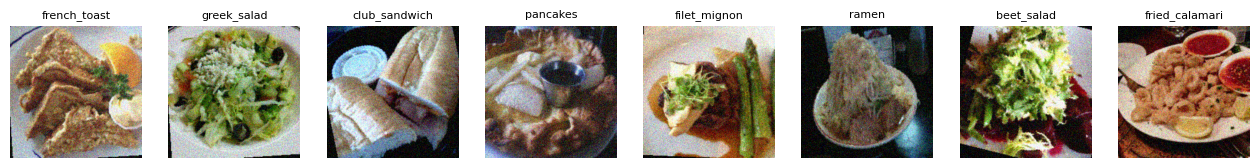

CutMix batch:


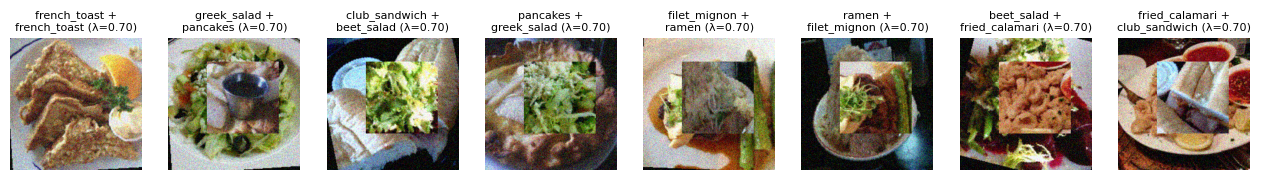

In [ ]:
def show_batch(images, labels, classes, mean, std, n=8, denorm=True):
    denorm_transform = Denormalize(mean, std)
    plt.figure(figsize=(16, 4))
    for i in range(min(n, len(images))):
        ax = plt.subplot(1, n, i+1)
        img = images[i]
        if denorm:
            img = denorm_transform(img)
            img = img.permute(1, 2, 0).cpu().numpy().clip(0, 1)
        else:
            img = img.permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        # Проверяем, является ли labels кортежем (CutMix) или тензором
        if isinstance(labels, tuple):
            labels_a, labels_b, lam = labels
            title = f"{classes[labels_a[i]]} +\n{classes[labels_b[i]]} (λ={lam:.2f})"
        else:
            title = classes[labels[i].item()]
        plt.title(title, fontsize=8)
        plt.axis("off")
    plt.show()

# CutMix для батча
def get_cutmix_bbox(img_size, lam):
    """Генерирует bounding box для CutMix"""
    H, W = img_size, img_size
    r_x = random.randint(0, W)
    r_y = random.randint(0, H)
    r_w = int(W * np.sqrt(1 - lam))
    r_h = int(H * np.sqrt(1 - lam))
    x1 = max(0, r_x - r_w // 2)
    x2 = min(W, r_x + r_w // 2)
    y1 = max(0, r_y - r_h // 2)
    y2 = min(H, r_y + r_h // 2)
    return x1, y1, x2, y2

def cutmix(images, labels, alpha=1.0, prob=0.5):
    """Применяет CutMix к батчу изображений, возвращает (images, (labels_a, labels_b, lam))"""
    batch_size = images.size(0)
    mixed_images = images.clone()
    labels_a = labels.clone()
    labels_b = labels.clone()
    lam = 1.0  # Если CutMix не применяется, lam=1, labels_b=labels_a

    if random.random() <= prob and batch_size > 1:  # batch_size > 1 для избежания ошибок
        index = torch.randperm(batch_size).to(images.device)
        lam = np.random.beta(alpha, alpha)
        x1, y1, x2, y2 = get_cutmix_bbox(images.size(-1), lam)
        for i in range(batch_size):
            mixed_images[i, :, y1:y2, x1:x2] = images[index[i], :, y1:y2, x1:x2]
        labels_b = labels[index]

    return mixed_images, (labels_a, labels_b, lam)

# Адаптируем FoodDataset для работы с torchvision
class FoodDataset(Dataset):
    def __init__(self, tv_dataset, transform=None):
        self.dataset = tv_dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        img = img.convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Тестируем CutMix на батче
train_ds_cutmix = FoodDataset(train_dataset, transform=transform_train)
batch_loader = DataLoader(train_ds_cutmix, batch_size=8, shuffle=True, num_workers=0)
batch = next(iter(batch_loader))
images, labels = batch

# Применяем CutMix
images_mixed, labels_mixed = cutmix(images, labels, 
                                    alpha=cfg.transforms.train.cutmix.alpha, 
                                    prob=cfg.transforms.train.cutmix.prob)

# Визуализация оригинального батча
print("Original batch:")
show_batch(images, labels, class_names, 
           mean=cfg.transforms.common.mean, std=cfg.transforms.common.std, n=8, denorm=True)

# Визуализация батча с CutMix
print("CutMix batch:")
show_batch(images_mixed, labels_mixed, class_names, 
           mean=cfg.transforms.common.mean, std=cfg.transforms.common.std, n=8, denorm=True)


In [ ]:
def show_batch(images, labels, classes, mean, std, n=8, denorm=True):
    denorm_transform = Denormalize(mean, std)
    plt.figure(figsize=(16, 4))
    for i in range(min(n, len(images))):
        ax = plt.subplot(1, n, i+1)
        img = images[i]
        if denorm:
            img = denorm_transform(img)
            img = img.permute(1, 2, 0).cpu().numpy().clip(0, 1)
        else:
            img = img.permute(1, 2, 0).cpu().numpy()
            img = (img - img.min()) / (img.max() - img.min())
        plt.imshow(img)
        # Проверяем, является ли labels тензором или списком кортежей
        if isinstance(labels, torch.Tensor):
            title = classes[labels[i].item()]
        else:  # labels - список кортежей от CutMix
            label1, label2, lam = labels[i]
            title = f"{classes[label1]} + {classes[label2]} (λ={lam:.2f})"
        plt.title(title, fontsize=8)
        plt.axis("off")
    plt.show()

# Truncated image showdown

 40%|███▉      | 30092/75750 [01:01<01:26, 526.96it/s]c:\Users\User\anaconda3\envs\superb\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Found truncated image at index 30105 (path: ): Truncated File Read


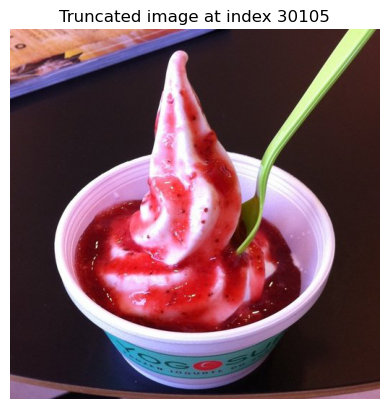

100%|██████████| 75750/75750 [02:35<00:00, 487.98it/s]


Problem indices: [30105]


 15%|█▌        | 3795/25250 [00:07<00:43, 497.90it/s]c:\Users\User\anaconda3\envs\superb\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Found truncated image at index 3803 (path: ): Truncated File Read


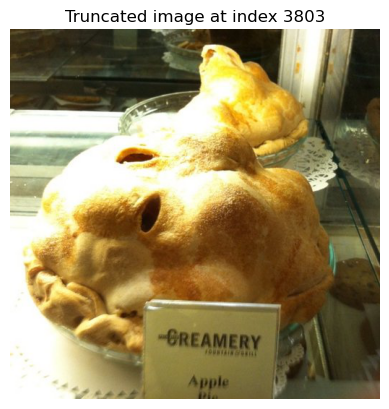

 35%|███▍      | 8814/25250 [00:18<00:33, 493.04it/s]

Found truncated image at index 8829 (path: ): Truncated File Read


c:\Users\User\anaconda3\envs\superb\Lib\site-packages\PIL\TiffImagePlugin.py:935: UserWarning: Truncated File Read
  warnings.warn(str(msg))


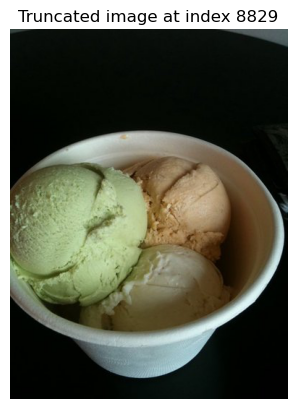

100%|██████████| 25250/25250 [00:51<00:00, 488.73it/s]

Problem indices: [30105, 3803, 8829]


In [ ]:
import warnings
from PIL import ImageFile

# Позволяет загружать "битые" изображения
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Поиск проблемных изображений
problem_indices_train = []
for idx in tqdm(range(len(train_dataset)), desc="Проверка train split"):
    try:
        img, _ = train_dataset[idx]
        # Попытка загрузить данные изображения, чтобы спровоцировать ошибку
        img.load()
    except Exception as e:
        print(f"Найдено проблемное изображение в train split на индексе {idx}: {e}")
        problem_indices_train.append(idx)
        plt.imshow(img)
        plt.title(f"Проблемное изображение: train, index {idx}")
        plt.axis("off")
        plt.show()

print(f"Проблемные индексы в train: {problem_indices_train}")

problem_indices_val = []
for idx in tqdm(range(len(val_dataset)), desc="Проверка val split"):
    try:
        img, _ = val_dataset[idx]
        img.load()
    except Exception as e:
        print(f"Найдено проблемное изображение в val split на индексе {idx}: {e}")
        problem_indices_val.append(idx)
        plt.imshow(img)
        plt.title(f"Проблемное изображение: val, index {idx}")
        plt.axis("off")
        plt.show()

print(f"Проблемные индексы в val: {problem_indices_val}")

# Сбрасываем флаг после проверки
ImageFile.LOAD_TRUNCATED_IMAGES = False